<p style="font-size:21px;">Da odgovorimo na vprašanje, kako se spreminja količine rojstev zunaj in v zakonski zvezi, smo našli podatke ki predstavljajo le to. Na žalost takšna statistika obstaja le za prvega rojenega otroka, kar je glede na podatke SURS približno polovica rojenih otrok.</p>

In [1]:
import re

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from fontTools.varLib.interpolatableHelpers import rot_list

ratings = pd.read_csv('raw/csv/rojstva_zakonske_zveze.csv', encoding="UTF-8")

def izvleci_stevilko(v):
    if pd.isna(v): return 0.0
    s = re.sub(r'[^\d,.]', '', str(v))
    if not s: return 0.0

    if '.' in s and ',' in s: s = s.replace('.', '').replace(',', '.')
    elif '.' in s and len(s.split('.')[-1]) == 3: s = s.replace('.', '')
    else: s = s.replace(',', '.')

    try: return float(s)
    except: return 0.0


<p style="font-size:18px;"> Da vidimo kako se količina rojstev zunaj in v zakonski zvezi, ustvarimo graf, kjer lahko zasledimo to spremembo skozi leta. Okoli leta 2000 lahko opazimo spremembo v statistiki, saj rojstva zunaj zakonske zveze postanejo bolj pogosti od rojstev v zakonski zvezi.  </p>

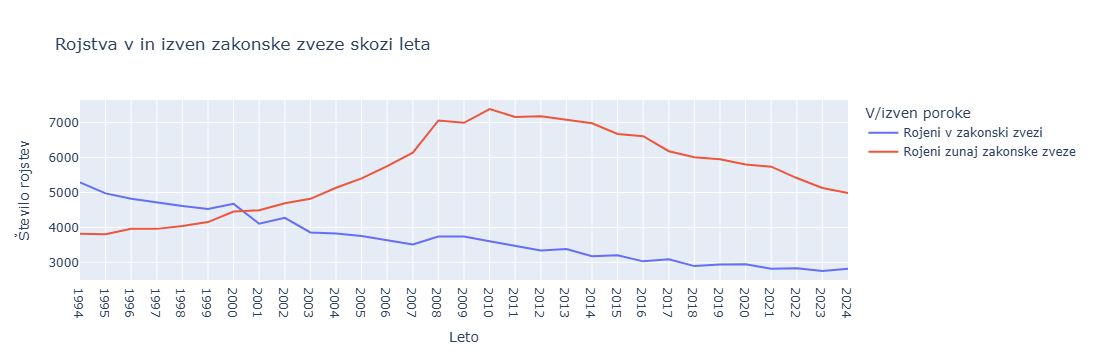

In [2]:
skupaj = ratings[ratings['Starostne skupine'] == 'Starostne skupine - SKUPAJ']
fig = px.line(
    skupaj,
    x='Leto',
    y=['Rojeni v zakonski zvezi', 'Rojeni zunaj zakonske zveze'],
    title='Rojstva v in izven zakonske zveze skozi leta',
    labels={
        'value': 'Število rojstev',
        'Leto': 'Leto',
        'variable': 'V/izven poroke'
    }
)

fig.show()


<p style="font-size:18px;">V tem grafu pa lahko vidimo količino rojstev v in zunaj zakonske zveze skozi leta glede na starostno skupino. Tako lahko poleg splošne količine rojstev vidimo tudi kako se ta količina spreminja med posameznimi starostnimi skupinami. </p>

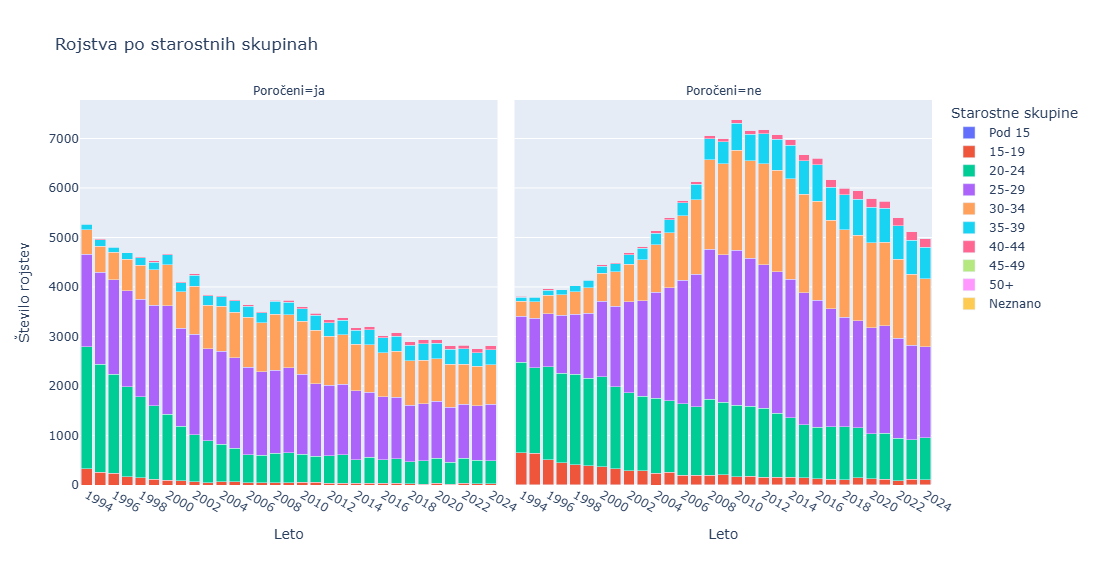

In [3]:
po_skupinah = ratings[ratings['Starostne skupine'] != 'Starostne skupine - SKUPAJ']

po_skupinah_long = po_skupinah.melt(
    id_vars=['Leto', 'Starostne skupine'],
    value_vars=['Rojeni v zakonski zvezi', 'Rojeni zunaj zakonske zveze'],
    var_name='Tip',
    value_name='Število'
)

po_skupinah_long['Tip'] = po_skupinah_long['Tip'].map({
    'Rojeni v zakonski zvezi': 'ja',
    'Rojeni zunaj zakonske zveze': 'ne'
})

fig = px.bar(
    po_skupinah_long,
    x='Leto',
    y='Število',
    color='Starostne skupine',
    barmode='stack',
    facet_col='Tip',
    labels={
        'Tip': 'Poročeni',
        'Število': 'Število rojstev'
    },
    title='Rojstva po starostnih skupinah'
)

fig.update_layout(width=1100, height=550)

fig.show()